In [7]:
import os
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [8]:
files = glob.glob('./dataview/*.xlsx')
files = [file for file in files if 'CoT' not in file]

scenario_map = {
    'binary-tree': 'Binary Tree',
    'multiple-tree': 'Multiple Tree',
    'JSON': 'JSON',
    'formula': 'Formula',
    'code': 'Code',
    'paper': 'Paper'
}

dfs = dict()

for file in files:
    try:
        scenario = scenario_map[os.path.basename(file).rstrip('.xlsx')]
        dfs[scenario] = pd.read_excel(file, sheet_name='ExampleType')
    except ValueError:
        continue

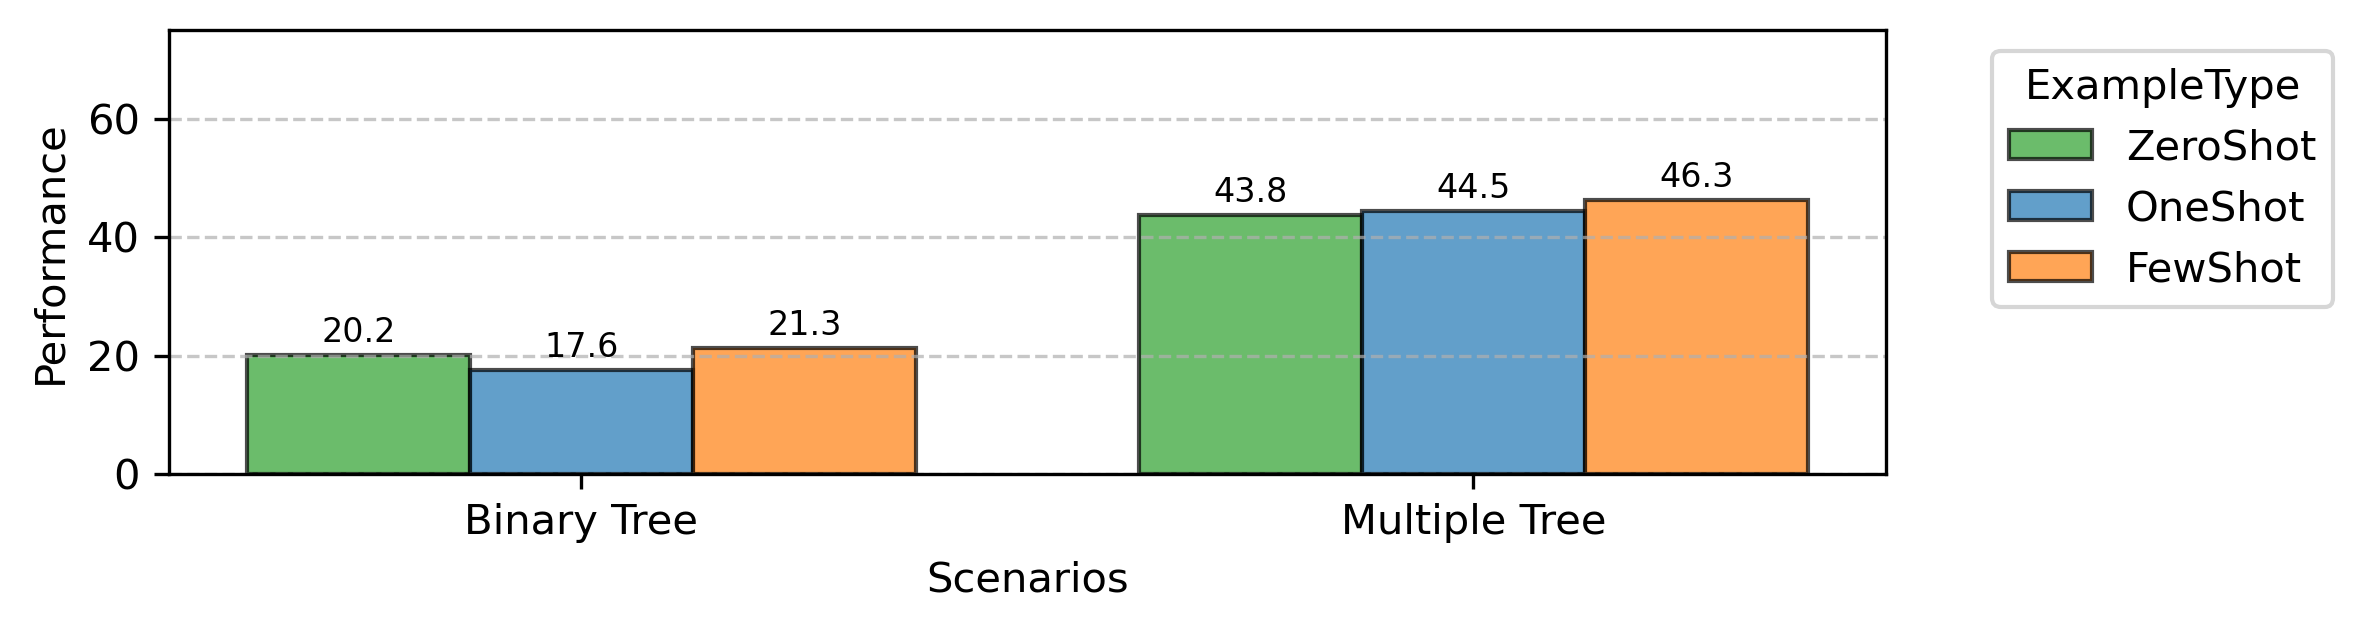

In [9]:
example_order = ['ZeroShot', 'OneShot', 'FewShot']
colors = {'ZeroShot': '#2ca02c', 'OneShot': '#1f77b4', 'FewShot': '#ff7f0e'}
scenario_order = ['Binary Tree', 'Multiple Tree']#, 'JSON', 'Formula', 'Code']


fig, ax = plt.subplots(figsize=(8, 2.2), dpi=300)

bar_width = 0.25
index = range(len(scenario_order))

for i, scenario in enumerate(scenario_order):
    df = dfs[scenario]
    filtered_data = df[df['ExampleType'].isin(example_order)]
    filtered_data = filtered_data.set_index('ExampleType').reindex(example_order).reset_index()

    bars = []
    for j, example_type in enumerate(example_order):
        example_type_data = filtered_data[filtered_data['ExampleType'] == example_type]
        bar = ax.bar(
            index[i] + bar_width * j, example_type_data['mean'].values[0], 
            color=colors[example_type], width=bar_width, alpha=0.7, label=example_type if i == 0 else "")
        bars.append(bar)

    for bar in bars:
        for rect in bar:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2, height + 1, f'{height:.1f}', 
                    ha='center', va='bottom', fontsize=8)

for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1)
    
ax.set_xlabel('Scenarios')
ax.set_ylabel('Performance')
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(scenario_order)
ax.set_ylim(0, 75)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='ExampleType', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()